# Student Performance Analysis System

**Team Members:**
- Abdelrahman Akram Ibrahim Mohammed Ibrahim ID: 2406242071
- Adham Ahmed Mohammed Abdelrazak ID: 2406244348
- Ahmed Mohamed Yakout Abdalrzaq ID: 2403249762
- Sara Ahmed Ali ID: 2406241505
- Haneen Mohammed Salheen ID: 2406241227 
- Zeina Ameer Mohammed ID: 2406242734

Introduction

- Dataset Description:
The dataset used in this project is the **Student Performance 
Factors** dataset, containing 6,607 student records across 
20 features covering academic, behavioral, and socioeconomic 
attributes such as study hours, attendance, motivation level, 
family income, and exam scores.

- Source:
The dataset was obtained from **Kaggle** :
[Link of the data set](https://www.kaggle.com/datasets/grandmaster07/student-exam-performance-dataset-analysis)
, a publicly available 
platform for real-world datasets. It is not a standard tutorial 
dataset (e.g., Iris or Titanic) and satisfies all project 
requirements: more than 1,000 instances, more than 6 features, 
and a mix of numeric and categorical attributes.

- Domain Motivation:
Student academic performance is a critical area of interest 
for educational institutions, policymakers, and researchers. 
Understanding which factors most influence exam outcomes allows 
schools to intervene early, allocate resources effectively, 
and personalize support for at-risk students. This dataset 
provides a realistic view of how behavioral and environmental 
factors interact with academic results, making it well-suited 
for clustering, fuzzy inference, and optimization tasks.

- Project Goal:
This project aims to uncover hidden patterns in student 
performance data, build an interpretable prediction system 
using Fuzzy Logic, and optimize feature selection using a 
Genetic Algorithm — ultimately producing an integrated system 
capable of classifying students and recommending interventions.

### Task 1: Exploratory Data Analysis & Visualization 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import warnings 
import skfuzzy as fuzz
import skfuzzy.control as ctrl
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, silhouette_samples

In [2]:
# Load the dataset
df = pd.read_csv('StudentPerformanceFactors.csv')

In [3]:
# number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6607
Number of columns: 20


In [4]:
# first 5 rows of the dataset
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


The first five rows provide an initial preview of the dataset structure and values for each feature.  
The dataset includes academic, personal, and family-related factors such as study hours, attendance, motivation, income level, and previous scores.  
These sample records show how different student conditions are associated with the target variable, **Exam_Score**.

In [5]:
# Display dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

The dataset contains **6,607 records** and **20 features**, providing a sufficient size for data mining analysis.  
It includes **7 numerical columns** and **13 categorical columns**, which gives a balanced mix of quantitative and qualitative data.  
Most columns are complete with no missing values, indicating good data quality overall.  
However, a few features such as **Teacher_Quality**, **Parental_Education_Level**, and **Distance_from_Home** contain some missing values.  
The memory usage is **1.0 MB**, making the dataset efficient to process.  
Overall, the dataset is well-structured and suitable for preprocessing, clustering, and predictive tasks.

In [6]:
# Display summary statistics
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


The summary statistics show that students study an average of **20 hours**, with attendance averaging nearly **80%**.  
The mean exam score is **67.24**, while most scores fall between **65 and 69**, indicating moderate academic performance overall.  
Sleep hours average around **7 hours**, which reflects a balanced routine for most students.  
Previous scores average **75**, suggesting students had fairly good prior academic results.  
Some variables have wide ranges, such as study hours (1 to 44) and tutoring sessions (0 to 8), showing different learning habits among students.  
Overall, the dataset contains realistic variation that is useful for identifying patterns affecting student success.

In [7]:
# Check for missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

The missing values analysis shows that most columns are complete with no missing data, which indicates strong overall data quality.  
Only three features contain missing values: **Teacher_Quality (78)**, **Parental_Education_Level (90)**, and **Distance_from_Home (67)**.  
Since the number of missing values is relatively small compared to 6,607 records, these can be handled effectively during preprocessing.  
Possible treatments include replacing missing categorical values with the mode or using advanced imputation techniques.  
The limited amount of missing data suggests that the dataset remains reliable for further analysis.  
Overall, no major data loss issue is present.

In [8]:
#numerical columns
num_cols = df.select_dtypes(include=['Int64', 'Float64']).columns
#categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

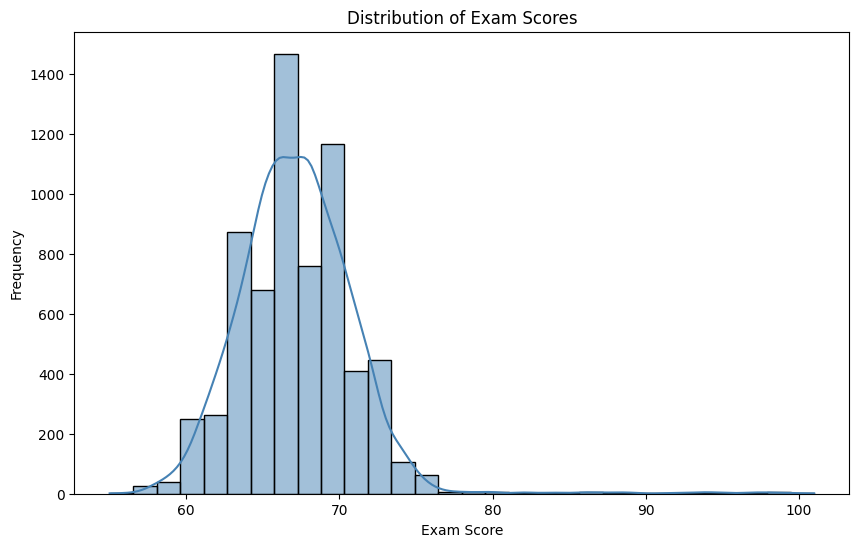

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df["Exam_Score"], bins=30, kde=True, color='steelblue')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

The histogram reveals that exam scores are right-skewed, with the majority of students scoring between 60 and 72. The distribution peaks around 67–68, indicating this is the most common score range among students. The KDE curve confirms the skewness, showing a sharp rise from scores in the low 60s and a long tail extending toward higher scores (80–101), which represent a small minority of high-achieving students.
This suggests that while most students perform at a moderate level, only a few achieve exceptionally high scores. The presence of scores near 100 indicates outliers or exceptionally well-prepared students. This skewed distribution may have implications for clustering in later tasks, as the majority of data points will be concentrated in the 60–75 range, and high scorers may form a distinct minority cluster.

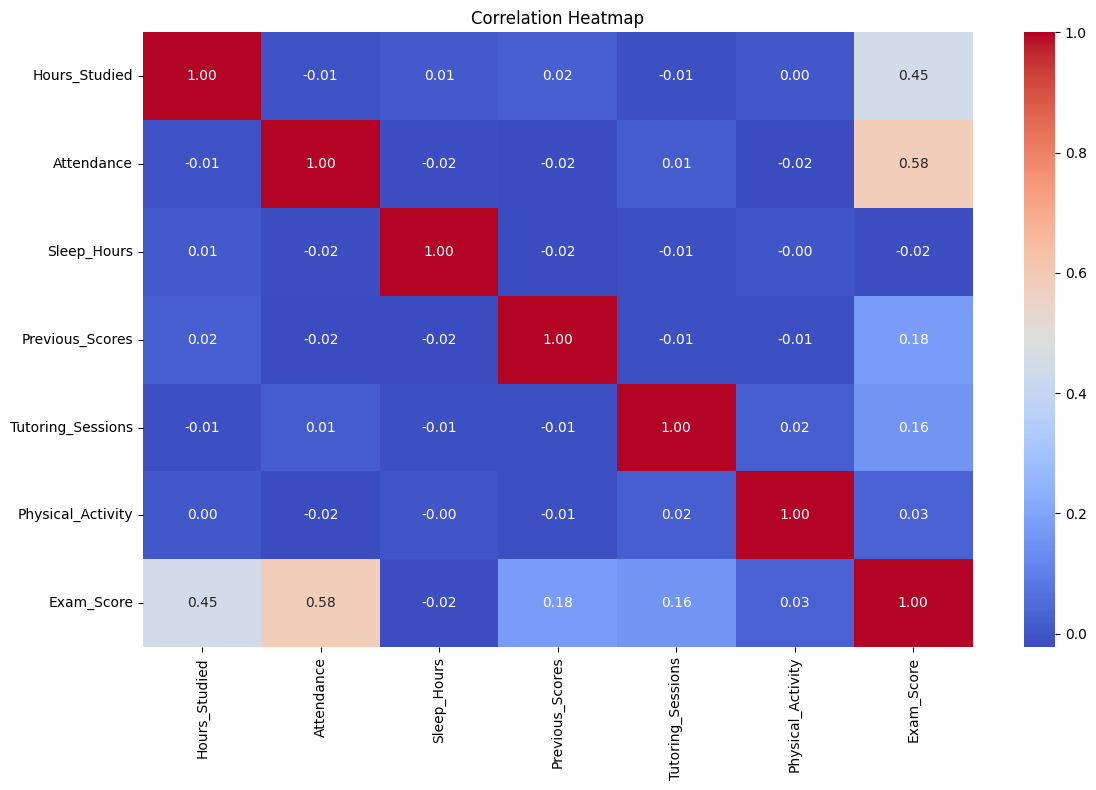

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

- The correlation heatmap reveals the linear relationships between all numerical features in the dataset. The key findings are as follows:
Strongest correlations with Exam_Score:

- Attendance (0.58) shows the strongest positive correlation with exam performance, suggesting that students who attend more classes consistently tend to score higher.
Hours_Studied (0.45) is the second strongest predictor, confirming that dedicated study time has a meaningful impact on outcomes.
Previous_Scores (0.18) and Tutoring_Sessions (0.16) show moderate but notable positive correlations, indicating that prior academic performance and additional tutoring support contribute to better results.

- Weak or negligible correlations:

- Sleep_Hours (−0.02) and Physical_Activity (0.03) show virtually no linear relationship with Exam_Score, suggesting these factors alone do not directly drive academic performance in this dataset.

- Inter-feature correlations:

- All feature pairs (excluding self-correlation) show near-zero correlation with each other, which is a positive sign — it indicates low multicollinearity, meaning each feature contributes relatively independent information to the model.

- Implication for later tasks: Since Attendance and Hours_Studied are the dominant numerical predictors of Exam_Score, these features will likely carry significant weight in clustering and fuzzy logic system design in subsequent tasks.


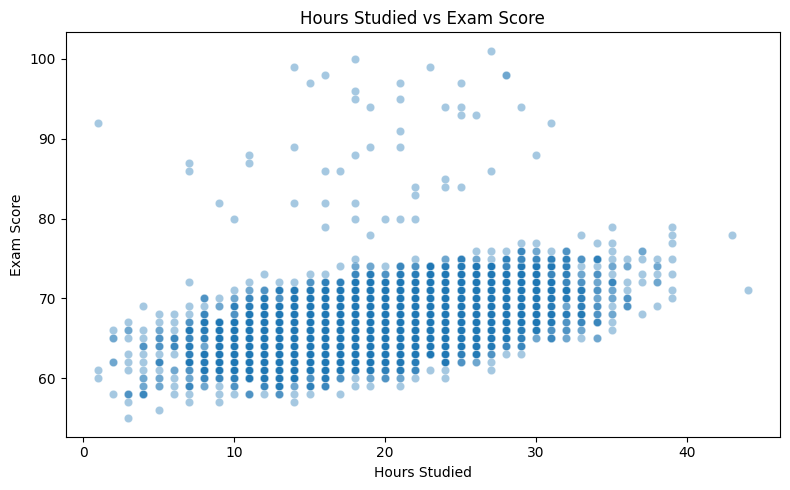

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df, alpha=0.4)
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

- The scatter plot illustrates the relationship between the number of hours studied per week and the corresponding exam score for each student.
Key observations:

- Positive trend: There is a clear upward trend — as Hours_Studied increases, Exam_Score generally increases as well. This is consistent with the correlation value of 0.45 observed in the heatmap.
Two distinct bands: The plot reveals an interesting structure with two visible layers of data points:

- A dense lower band ranging from scores of roughly 55–78, which contains the vast majority of students and shows a gradual upward slope with more study hours.
A sparse upper band of high-scoring students (scores 78–101), scattered across all study hour ranges, suggesting that some students achieve exceptional scores regardless of study hours — possibly due to other factors like talent, prior knowledge, or tutoring.


- Low study hours, variable scores: Students studying fewer than 10 hours show a wide range of scores (55–92), indicating that hours studied alone does not fully explain performance at the lower end.
Diminishing spread at higher hours: Beyond 25 hours, scores become more consistently concentrated in the 65–78 range, with fewer extreme outliers, suggesting a ceiling effect for average students.
Outliers: A small number of data points appear far above the main cluster (scores above 85 with moderate study hours), which may represent academically exceptional students or data anomalies worth noting during preprocessing.

- Implication for later tasks: The two-band structure hints at the possibility of natural student clusters based on performance level, which may be captured effectively by K-Medoid clustering in Task 3.

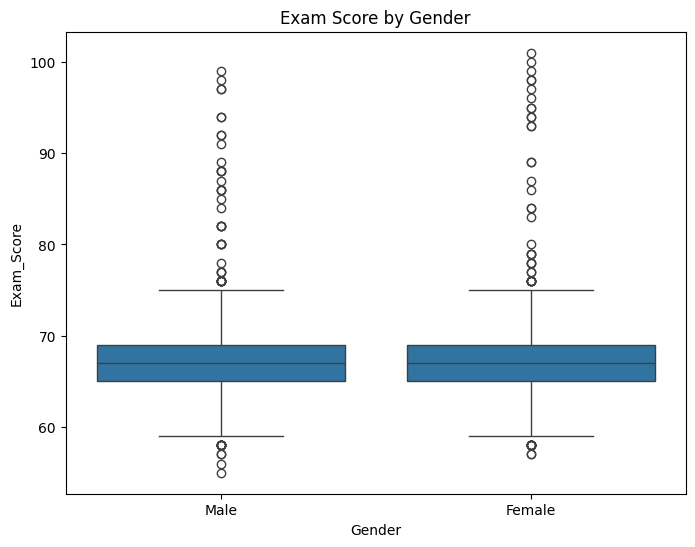

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x="Gender", y="Exam_Score", data=df)
plt.title("Exam Score by Gender")
plt.show()

- The box plot compares the distribution of Exam_Score between male and female students.
Key observations:

- Nearly identical medians: Both male and female students share almost the same median exam score of approximately 67, indicating that gender alone does not confer a meaningful academic advantage in this dataset.
Similar IQR (Interquartile Range): The boxes for both groups span roughly from 64 to 68, meaning the middle 50% of students in both genders perform within the same narrow score range. This confirms a very tight and consistent performance distribution regardless of gender.
- Same whisker range: Both groups extend from approximately 59 to 75, showing that the typical score boundaries are virtually identical across genders.
- Outliers present in both groups: Both male and female students have notable upper outliers reaching scores of 98–101, as well as a few lower outliers around 55–58. These exceptional cases exist equally across both genders, reinforcing that high and low performance is not gender-dependent.
- Slightly more upper outliers in females: The female group appears to have marginally more data points above 90, though the difference is minimal and not statistically conclusive from visual inspection alone.

- Implication for later tasks: Since gender shows no meaningful difference in exam performance, it is unlikely to be a strong discriminating feature in clustering. However, it may still be included as a categorical variable during preprocessing for completeness, as it could interact with other features in the Fuzzy Logic system.

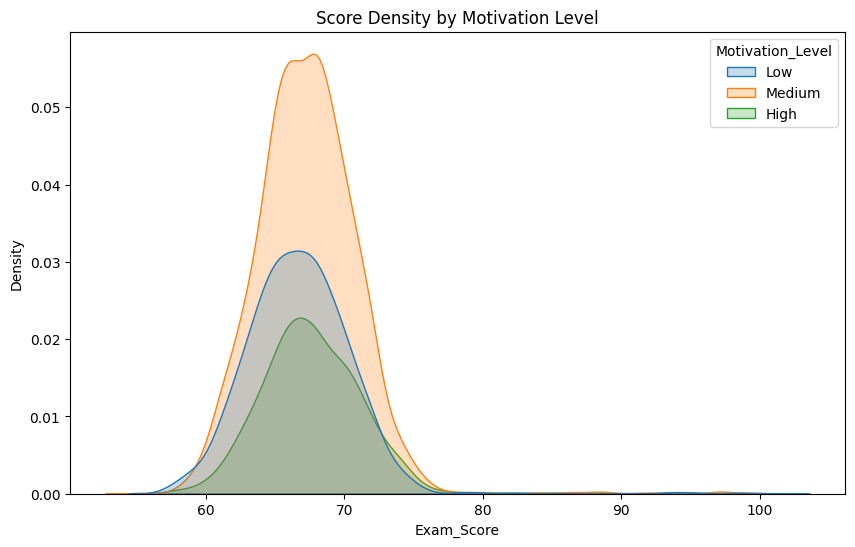

In [13]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x="Exam_Score",
    hue="Motivation_Level",
    fill=True
)

plt.title("Score Density by Motivation Level")
plt.show()

The KDE plot displays the distribution of Exam_Score across three motivation levels:
Low, Medium, and High.

All three groups share nearly identical score distributions, with peaks centered
around 67–68. This confirms that motivation level alone has minimal direct impact
on exam performance — the differences between groups are negligible.

Notably, the Medium motivation group shows the sharpest and tallest peak,
indicating that the majority of students fall in this category and their scores
are more tightly concentrated around the mean.

The Low and High motivation groups show wider, flatter distributions, suggesting
more variation in scores within these groups despite their different motivation levels.

All three curves extend similarly toward higher scores (80–101), meaning that
high-achieving outliers exist across all motivation levels equally.

Overall, this plot reinforces the earlier finding from the bar chart — motivation
is likely an indirect factor that influences study behavior rather than a direct
predictor of exam outcomes.

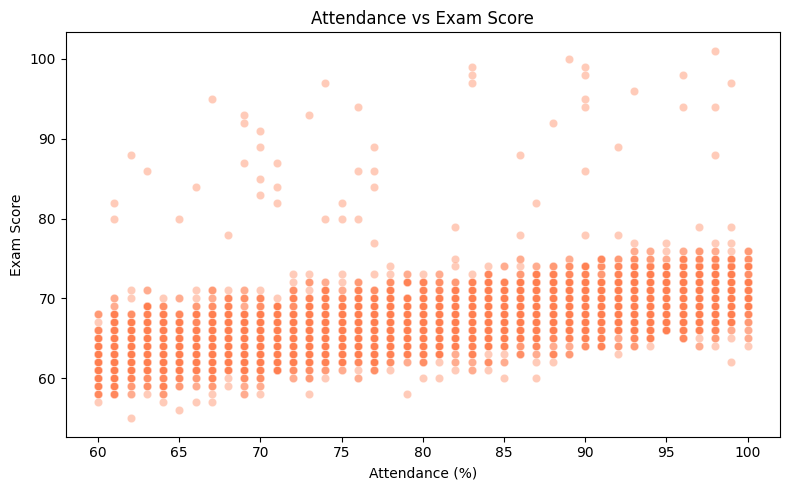

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Attendance", y="Exam_Score", data=df, alpha=0.4, color='coral')
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

- The scatter plot examines the relationship between student attendance percentage and their corresponding exam score.
Key observations:

- Clear positive trend: As attendance increases from 60% to 100%, exam scores show a visible upward shift, consistent with the strongest correlation observed in the heatmap (0.58). Students with higher attendance rates are more likely to achieve higher exam scores.
Two-band structure (again): Similar to the Hours_Studied scatter plot, this chart also displays two distinct layers:

- A dense lower band (scores 55–78) containing the majority of students, showing a gradual upward slope as attendance increases.
A sparse upper band (scores 78–101) of high-performing outliers scattered across all attendance levels, suggesting that exceptional students exist even at lower attendance rates.


- High variance at low attendance: Students with attendance below 70% show a surprisingly wide range of scores (55–95), indicating that some students can compensate for low attendance through self-study or prior knowledge, while others suffer significantly.
Score floor rises with attendance: At higher attendance rates (90–100%), the minimum scores observed tend to be higher, meaning that very low scores become increasingly rare among highly-attending students. This suggests attendance acts as a protective factor against poor performance.
- Ceiling remains consistent: Despite attendance reaching 100%, scores rarely exceed 80 in the main cluster, reinforcing that attendance alone cannot push a student into the top-performing tier — other factors must also be present.

- Implication for later tasks: Attendance is the strongest single numerical predictor of exam performance and should be a primary input feature in both the K-Medoid clustering and the Fuzzy Logic inference system. Its combination with Hours_Studied is likely to define the most meaningful student performance clusters.

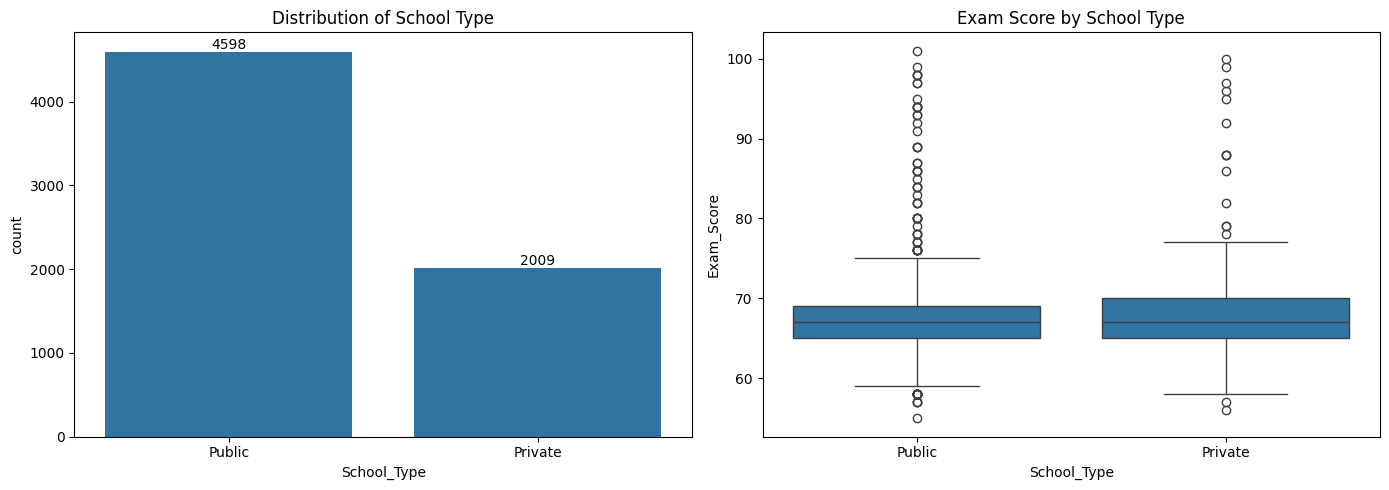

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#School Type distribution
sns.countplot(x="School_Type", data=df, ax=axes[0])
axes[0].set_title("Distribution of School Type")

for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2., p.get_height(), int(p.get_height()), 
                 ha='center', va='bottom')
#School Type vs Exam Score
sns.boxplot(x="School_Type", y="Exam_Score", data=df, ax=axes[1])
axes[1].set_title("Exam Score by School Type")
plt.tight_layout()
plt.show()

- School Type Distribution: The dataset contains approximately 4,598 public school students
and 2,009 private school students, meaning public schools represent ~70% of the data.
This imbalance should be considered during modeling, as patterns will be more representative
of public school students.

- Exam Score by School Type: Both public and private school students share almost identical
score distributions, with medians around 67–68 and similar IQR ranges. Private school
students show slightly fewer extreme outliers. Overall, school type does not significantly
differentiate academic performance in this dataset.

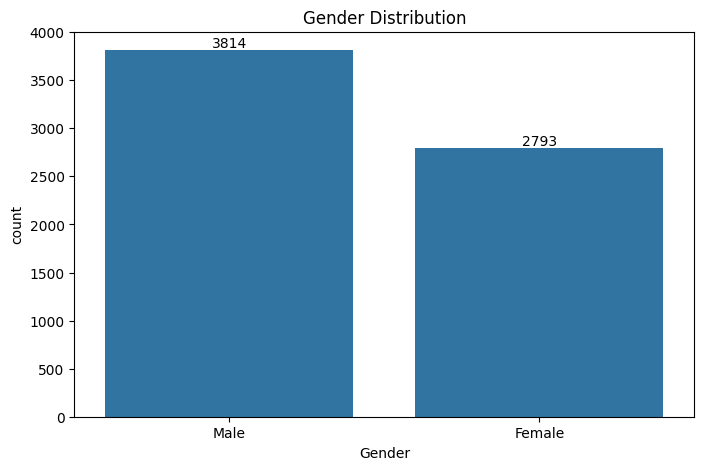

Text(0.5, 1.0, 'Family Income Distribution')

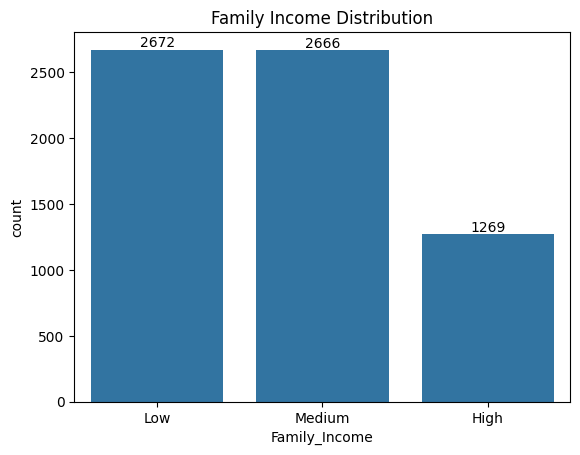

In [16]:

plt.figure(figsize=(8,5))
ax = sns.countplot(x="Gender", data=df)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(), int(p.get_height()), ha='center', va='bottom')

plt.title("Gender Distribution")
plt.show()
a = sns.countplot(x="Family_Income", data=df, order=["Low","Medium","High"])

for p in a.patches:

    a.text(p.get_x() + p.get_width()/2, p.get_height(), int(p.get_height()), ha='center', va='bottom')

plt.title("Family Income Distribution")

- Gender Distribution:
The dataset contains more male students (3,814) than female (2,793),
with males representing ~58% of the data. This slight imbalance
should be noted but is unlikely to significantly affect the analysis.

- Family Income Distribution:
Low and Medium income groups are nearly equal in size 2672 , 2666 respectivily 
together representing ~80% of students. High income students
represent only ~19% of the dataset.

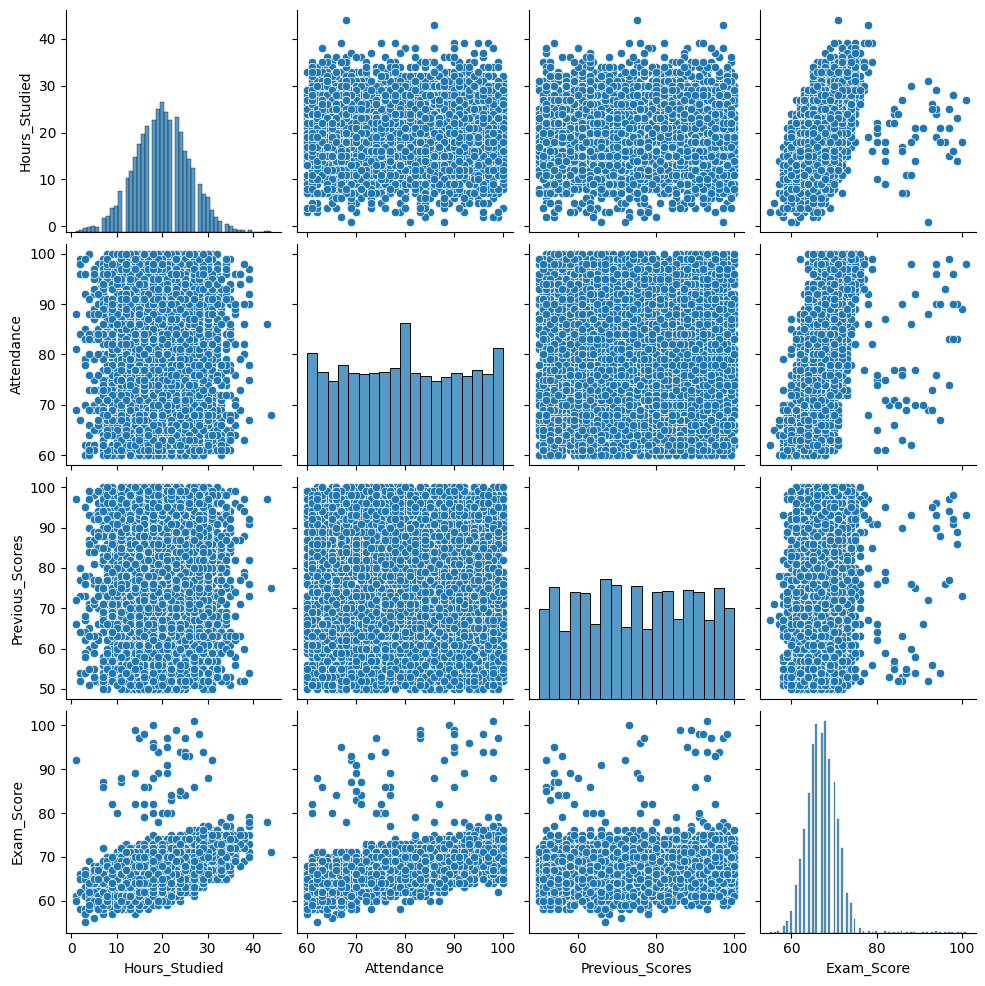

In [17]:
sns.pairplot(df[["Hours_Studied","Attendance","Previous_Scores","Exam_Score"]])
plt.show()

- Pairplot shows positive relationships between Hours_Studied, Attendance, Previous_Scores, and Exam_Score.
Students with stronger academic habits generally achieve better results.

### EDA Conclusion:

Exploratory analysis revealed that Attendance is the strongest predictor of exam performance with a correlation of 0.58, followed by Hours_Studied (0.45). Motivation level and Gender showed negligible impact on scores. The score distribution is right-skewed, with most students scoring between 60–72, and a small minority exceeding 80. Family income and school type showed no meaningful differentiation in performance.
Business Value: Educational institutions should prioritize attendance monitoring over study-hour tracking as an early warning system for at-risk students.
Action: Implement an attendance-based alert system — students below 70% attendance should be flagged for intervention before exam season.

### Task 2: Data Preprocessing

- Data preprocessing is a crucial step that prepares raw data for analysis. It involves cleaning and transforming the dataset by handling missing values, removing duplicates, encoding categorical variables, and scaling features to ensure accurate and reliable results.

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

- This step is used to display a summary of the dataset. It provides information about the number of entries, column names,
data types, and missing values in each column. This helps in understanding the structure of the dataset and identifying which
columns require preprocessing.

In [19]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

- This step is used to check the number of missing values in each column of the dataset.
It also helps us decide which techniques are best to remove those missing values

In [20]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

- Missing values were handled by filling numerical columns with the median and categorical columns with mode. 
- The median was used because it is less affected by outliers, while the mode represents the most frequent category.

In [21]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

- This displays the columns after removing the missing values

In [22]:
# Count duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


- This step checks for duplicate rows in the dataset. Duplicate data can affect the accuracy of the analysis and model performance, so it is important to identify how many repeated rows exist so we can remove them.

In [23]:
df.drop(columns=["Gender", "School_Type", "Internet_Access", "Family_Income"], inplace=True)

- These columns were removed because they are not directly related to academic performance.

- Gender:

Exam scores are mainly based on studying and understanding, gender does not determine academic performance.

- School_Type:

Schools may differ, but performance depends more on the student’s effort, so it’s not a strong direct factor.

- Internet_Access:

Internet can help, but it doesn’t guarantee better performance, students can still perform well without it.

- Family_Income:

Income might affect opportunities, but exam scores still mainly depend on the student’s work and ability.

- Therefore, these features were excluded to simplify the model and focus on more relevant variables.

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Tutoring_Sessions           6607 non-null   int64
 9   Teacher_Quality             6607 non-null   str  
 10  Peer_Influence              6607 non-null   str  
 11  Physical_Activity           6607 non-null   int64
 12  Learning_Disabilities       6607 non-null   str  
 13  Parental_Education_Level    6607 non-null   str  
 14  Distance_from_Home 

- This displays the columns in the dataset after dropping the irrelevant columns.

In [25]:
for col in df.select_dtypes(include=['int64', 'float64']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)

- This step is used for removing the outliers from the numerical columns.

In [26]:
df = pd.get_dummies(df, drop_first=True)

- One-Hot encoding was used to convert categorical columns into a numerical form by creating binary columns for each category. The drop_first=True was applied to avoid multicollinearity by removing one redundant category from each feature.

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Hours_Studied                          6607 non-null   int64  
 1   Attendance                             6607 non-null   int64  
 2   Sleep_Hours                            6607 non-null   int64  
 3   Previous_Scores                        6607 non-null   int64  
 4   Tutoring_Sessions                      6607 non-null   float64
 5   Physical_Activity                      6607 non-null   int64  
 6   Exam_Score                             6607 non-null   int64  
 7   Parental_Involvement_Low               6607 non-null   bool   
 8   Parental_Involvement_Medium            6607 non-null   bool   
 9   Access_to_Resources_Low                6607 non-null   bool   
 10  Access_to_Resources_Medium             6607 non-null   bool   
 11  Extracurricular

- After applying OHE, the number of columns increased because each categorical column was transformed into multiple binary columns. All features are now in numerical form which makes the dataset suitible for further data analysis.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

- Standardization was performed using StandardScaler to bring all features to a common scale with mean 0 and standard deviation 1. This ensures that differences in feature ranges do not affect the analysis.

In [29]:
print(df_scaled.head())

   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0       0.508885    0.348375    -0.019796        -0.143800          -1.310621   
1      -0.163320   -1.383736     0.661399        -1.116110           0.514305   
2       0.676936    1.560853    -0.019796         1.106313           0.514305   
3       1.517192    0.781403     0.661399         1.592469          -0.398158   
4      -0.163320    1.041220    -0.700990        -0.699406           1.426768   

   Physical_Activity  Exam_Score  Parental_Involvement_Low  \
0           0.031411   -0.037697                  1.985362   
1           1.001199   -1.816712                  1.985362   
2           1.001199    2.037821                 -0.503687   
3           1.001199    1.148313                  1.985362   
4           1.001199    0.851811                 -0.503687   

   Parental_Involvement_Medium  Access_to_Resources_Low  ...  \
0                    -1.017868                -0.498013  ...   
1           

- This shows the first 5 scaled values of each column or feature.

In [30]:
df_scaled.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Motivation_Level_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near
count,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,...,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03
mean,-2.150879e-17,-3.089199e-16,-2.016449e-16,2.048712e-16,-5.323424e-17,-1.720703e-17,-1.789531e-15,-8.065795e-18,3.656494e-17,-5.162109e-17,...,-8.495970e-17,-8.173339e-17,1.441089e-16,8.711058e-17,-4.516845e-17,-1.989563e-17,2.903686e-17,7.205443e-17,-6.613952e-17,1.677685e-16
std,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,...,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00,1.000076e+00
min,-2.684089e+00,-1.730158e+00,-2.063380e+00,-1.741167e+00,-1.310621e+00,-2.877953e+00,-2.409717e+00,-5.036866e-01,-1.017868e+00,-4.980127e-01,...,-1.014484e+00,-3.322953e-01,-1.239859e+00,-8.034794e-01,-8.152613e-01,-3.428666e-01,-1.002880e+00,-4.961185e-01,-6.584069e-01,-1.219662e+00
25%,-6.674741e-01,-8.641026e-01,-7.009903e-01,-8.383073e-01,-3.981582e-01,-9.383768e-01,-6.307018e-01,-5.036866e-01,-1.017868e+00,-4.980127e-01,...,-1.014484e+00,-3.322953e-01,-1.239859e+00,-8.034794e-01,-8.152613e-01,-3.428666e-01,-1.002880e+00,-4.961185e-01,-6.584069e-01,-1.219662e+00
50%,4.730972e-03,1.953115e-03,-1.979558e-02,-4.898448e-03,-3.981582e-01,3.141133e-02,-3.769670e-02,-5.036866e-01,9.824456e-01,-4.980127e-01,...,9.857232e-01,-3.322953e-01,8.065433e-01,-8.034794e-01,-8.152613e-01,-3.428666e-01,9.971284e-01,-4.961185e-01,-6.584069e-01,8.198993e-01
75%,6.769360e-01,8.680088e-01,6.613991e-01,8.979612e-01,5.143050e-01,1.001199e+00,5.553084e-01,-5.036866e-01,9.824456e-01,-4.980127e-01,...,9.857232e-01,-3.322953e-01,8.065433e-01,1.244587e+00,1.226601e+00,-3.428666e-01,9.971284e-01,-4.961185e-01,1.518818e+00,8.198993e-01
max,2.693551e+00,1.734065e+00,2.023788e+00,1.731370e+00,1.883000e+00,2.940776e+00,2.334324e+00,1.985362e+00,9.824456e-01,2.007981e+00,...,9.857232e-01,3.009371e+00,8.065433e-01,1.244587e+00,1.226601e+00,2.916586e+00,9.971284e-01,2.015648e+00,1.518818e+00,8.198993e-01


- This provides a summary of the statistics of the scaled dataset, such as mean, standard deviation, min, max, etc. 

### Preprocessing Conclusion:

The following transformations were applied in order:
1. **Missing Values:** Numerical filled with median, 
   categorical with mode.
2. **Duplicates:** No duplicate rows found.
3. **Feature Dropping:** 4 features removed (Gender, School_Type,
   Internet_Access, Family_Income) — EDA confirmed no meaningful 
   impact on Exam_Score.
4. **Outlier Treatment:** IQR clipping applied to numerical columns
   before encoding to avoid affecting binary features.
5. **Encoding:** One-Hot Encoding with drop_first=True to avoid 
   multicollinearity.
6. **Scaling:** StandardScaler normalized all features to mean=0, 
   std=1 — essential for clustering and fuzzy logic accuracy.

## Task 3: K-Medoid Clustering  

In [31]:
cluster_features = ['Hours_Studied', 'Attendance','Previous_Scores', 'Tutoring_Sessions']
# Scale selected features
scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(df[cluster_features])
print("Features used for clustering:", cluster_features)
print("Data shape:", X_scaled.shape)

Features used for clustering: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']
Data shape: (6607, 4)


Step 1: Determine Optimal Number of Clusters
The Elbow Method and Silhouette Score are used together to find the best k.
- Elbow Method: looks for the point where inertia stops decreasing sharply.
- Silhouette Score: measures how well each point fits its cluster (higher = better).

In [32]:
inertias = []
sil_scores = []
K_range = range(2, 8)

for k in K_range:
    km = KMedoids(n_clusters=k, random_state=42, metric='manhattan')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k} → Inertia: {km.inertia_:.2f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}")

k=2 → Inertia: 19261.87 | Silhouette: 0.1856
k=3 → Inertia: 17554.54 | Silhouette: 0.1696
k=4 → Inertia: 16503.22 | Silhouette: 0.1645
k=5 → Inertia: 15616.39 | Silhouette: 0.1593
k=6 → Inertia: 14969.43 | Silhouette: 0.1638
k=7 → Inertia: 14681.99 | Silhouette: 0.1228


Step 2: Elbow & Silhouette Plots

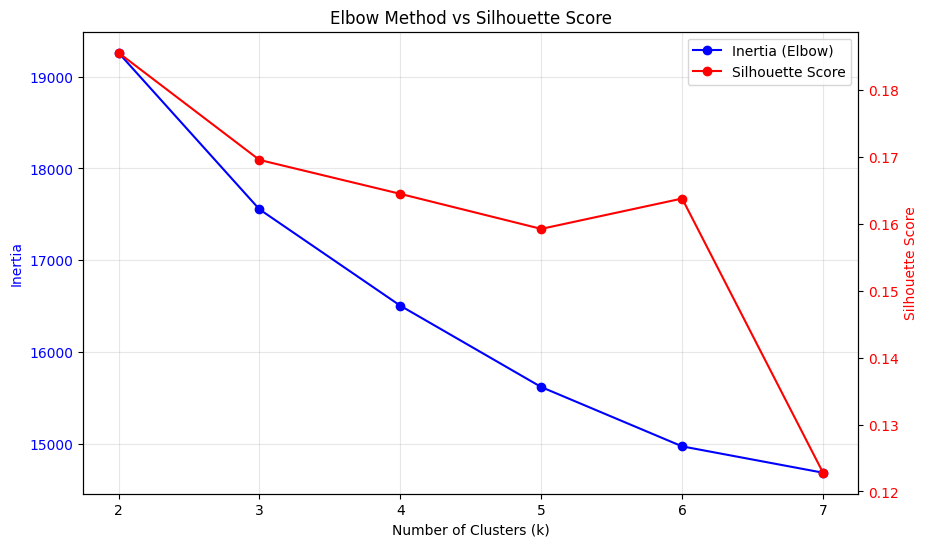

Best k by Silhouette Score: 2


In [33]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Elbow Method (Inertia)
ax1.plot(K_range, inertias, marker='o', color='blue', label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Silhouette Score (second axis)
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, marker='o', color='red', label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Elbow Method vs Silhouette Score")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.show()

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"Best k by Silhouette Score: {best_k}")

Both methods agree on **k=2** as the optimal number of clusters.

The **Elbow Plot** shows the sharpest drop in inertia between k=2 and k=3,
after which improvements become marginal.

The **Silhouette Score** is highest at k=2 (**0.1856**).

**Note on Silhouette Score magnitude:** A silhouette score of ~0.19 is
considered low-to-moderate, which is expected in this dataset. Student
performance data is inherently continuous — no sharp natural boundaries
exist between 'high' and 'low' performers. Despite the moderate score,
k=2 provides the most meaningful grouping: **high-engagement/high-performing**
vs **low-engagement/at-risk** students.

In [34]:
# Fit final model with best k
km_final = KMedoids(n_clusters=best_k, random_state=42, metric='manhattan')
df['Cluster'] = km_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    3434
1    3173
Name: count, dtype: int64


After applying **K-Mediods** the data is divided into two balanced clusters. 
This indicated that both clusters represents a large amout of the dataset

Step 3: Cluster Profiles

In [35]:
profile = df.groupby('Cluster')[cluster_features + ['Exam_Score']].mean().round(2)
print("=== Cluster Profiles ===")
print(profile)


=== Cluster Profiles ===
         Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions  \
Cluster                                                                  
0                19.88       89.55            74.52               1.46   
1                20.07       69.62            75.66               1.41   

         Exam_Score  
Cluster              
0             68.94  
1             65.17  


The clustering results shows that there are two groups of students divided as the following:

- Group 0:
  - Similar study hours (~19.88 hrs/week)
  - Higher attendance rate (~89.55%)
  - Higher exam score (~68.94)
  - Higher previous scores (~74.52)
  
This group represents **more engaged and higher-performing students**.

- Group 1:
  - Similar study hours (~20.07 hrs/week)
  - Lower attendance rate (~69.62%)
  - Lower exam score (~65.17)
  - Lower previous scores (~75.66)

This group represents **less engaged students who may need academic support**.

### What we get:
The main differentiator between the two clusters is **Attendance**, not study hours — both groups study roughly the same amount (~20 hrs/week). This suggests that physically attending classes has a stronger impact on exam performance than hours studied alone.

Step 4: Cluster Visualization

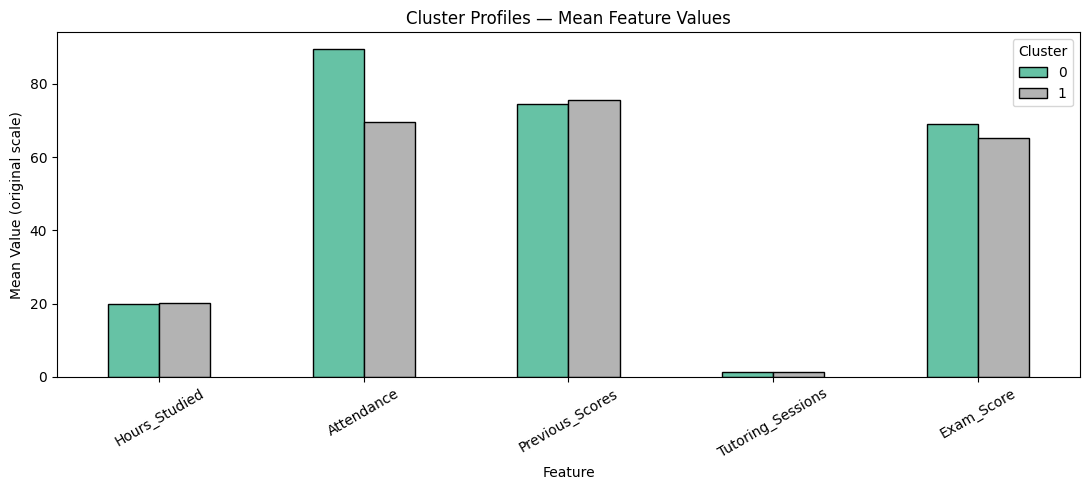

In [36]:
# Visualize cluster profiles as bar chart
profile.T.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='black')
plt.title("Cluster Profiles — Mean Feature Values")
plt.xlabel("Feature")
plt.ylabel("Mean Value (original scale)")
plt.xticks(rotation=30)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

To better understand the clustering we used barchart to compare between both of the clusters.
From the plot its clear that **cluster(0)** has high values for almost all features while **cluster(1)** has lower values for them.
### This proves that:
 **cluster(0)** represents higher-performing students while **cluster(1) represents students that needs support**

Step 5: Silhouette Plot per Sample

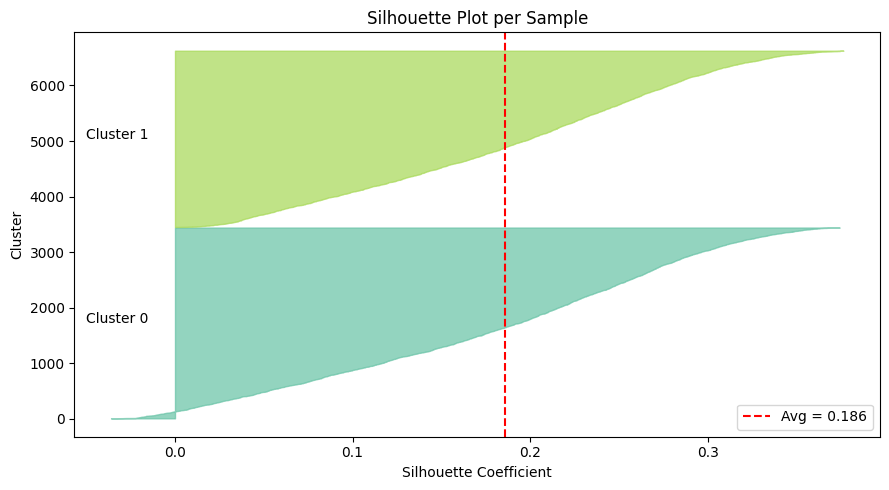

In [37]:
sil_vals = silhouette_samples(X_scaled, df['Cluster'])
fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for i in range(best_k):
    cluster_sil = np.sort(sil_vals[df['Cluster'] == i])
    size = cluster_sil.shape[0]
    y_upper = y_lower + size
    color = cm.Set2(i / best_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}')
    y_lower = y_upper + 10
ax.axvline(x=silhouette_score(X_scaled, df['Cluster']), color='red',linestyle='--', label=f'Avg = {silhouette_score(X_scaled, df["Cluster"]):.3f}')
ax.set_title("Silhouette Plot per Sample")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()

To evaluate the quality of clustering at a deeper level, we used a **silhouette plot**, which shows how well each data point fits within its assigned cluster.

### What does it mean:

- Each horizontal section represents a cluster
- Each bar represents a data point’s silhouette value
- The width of each bar shows how well that point fits its cluster:
  - Close to 1 → well-clustered
  - Around 0 → overlapping clusters
  - Negative → possibly misclassified

### What we get:
- There are a few negative values indicating some overlap between clusters, 
which is expected given the continuous nature of student performance data. 
Overall, the majority of points have positive values confirming the clustering is meaningful.

### K-Medoids Conclusion:

K-Medoids clustering with k=2 (silhouette = 0.186) divided students into two meaningful groups. Cluster 0 represents high-engagement students with average attendance of 89.55% and exam score of 68.94. Cluster 1 represents at-risk students with attendance of only 69.62% despite similar study hours (~20hrs/week for both groups). The key finding is that attendance — not study hours — is the primary differentiator between the two clusters.
Business Value: Students can be automatically classified into support tiers based on behavioral patterns, not just grades.
Action: Students in Cluster 1 should receive targeted interventions such as mandatory tutoring or counseling, since their study effort is equal to Cluster 0 but their attendance is dragging their performance down.

# Task 4: Hierarchical Clustering

### 1) Dendrogram Plot

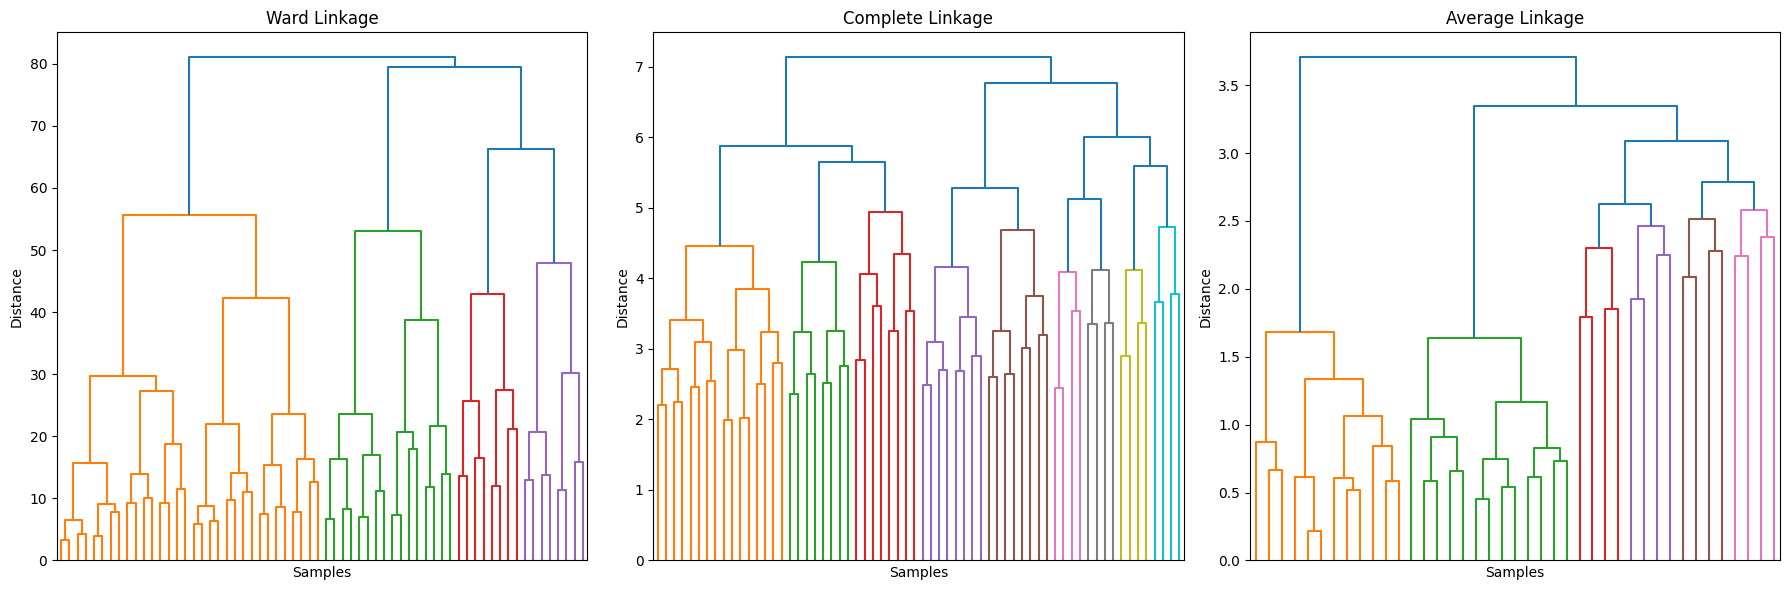

In [38]:

# LINKAGE METHODS
linkage_methods = ['ward', 'complete', 'average']
linkage_matrices = {
    method: linkage(X_scaled, method=method)
    for method in linkage_methods
}

# DENDROGRAM VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, method in enumerate(linkage_methods):
    dendrogram(
        linkage_matrices[method],
        ax=axes[i],
        truncate_mode='level',
        p=5,
        no_labels=True
    )
    axes[i].set_title(f"{method.capitalize()} Linkage")
    axes[i].set_xlabel("Samples")
    axes[i].set_ylabel("Distance")

plt.tight_layout()
plt.show()




### Linkage Methods and Dendrogram Visualization

In this step, we apply Hierarchical Clustering using three different linkage methods:
- Ward Linkage
- Complete Linkage
- Average Linkage

Each method determines how the distance between clusters is calculated:
- **Ward** minimizes variance within clusters.
- **Complete** uses the maximum distance between points.
- **Average** uses the average distance between points.

We then use dendrogram to visualize this clustering. These plots show how clusters are merged step by step.


### 2) Determining the optimal number of clusters using the Silhouette Score


In [39]:
K_range = range(2, 8)
sil_results = {} 
for method in linkage_methods:
    sil_scores = []
    for k in K_range:
        clusterer = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = clusterer.fit_predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, labels))
    sil_results[method] = sil_scores
    print(f"{method.capitalize()} Linkage Silhouette Scores: {sil_scores}") 

Ward Linkage Silhouette Scores: [0.12280623138561036, 0.1295770659137004, 0.1285148168146461, 0.12241013199360398, 0.12909074149142352, 0.12813088962928143]
Complete Linkage Silhouette Scores: [0.1343376797836548, 0.1040697896283795, 0.10757907311462679, 0.11016556212736779, 0.10236427689597351, 0.08865366184028417]
Average Linkage Silhouette Scores: [0.24433988828808526, 0.06682526723023417, 0.08730109751050132, 0.10576710151781234, 0.08600984042932594, 0.0927648071635359]


Hierarchical clustering was evaluated using three different linkage methods: Ward, Complete, and Average. For each method, different numbers of clusters (K = 2 to 7) were tested in order to determine the optimal cluster configuration.

The Silhouette Score was used as the evaluation metric A higher score indicates better-defined and more separated clusters, while lower or negative values indicate overlapping clusters.

Across all linkage methods, K = 2 consistently provides the best clustering quality.

### 3) SILHOUETTE SCORES PLOT

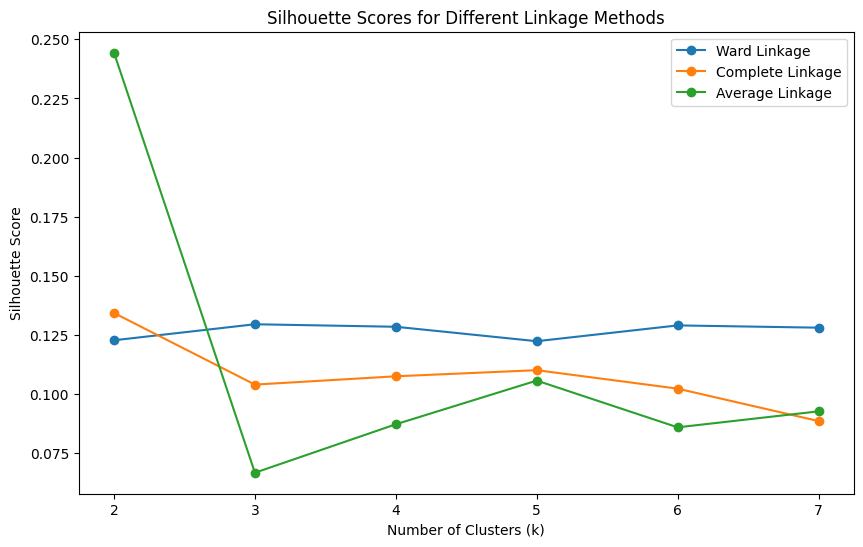

In [40]:
plt.figure(figsize=(10, 6))
for method in linkage_methods: 
    plt.plot(K_range, sil_results[method], marker='o', label=f"{method.capitalize()} Linkage")
plt.title("Silhouette Scores for Different Linkage Methods")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()  

This line plot illustrates the relationship between the number of clusters (K) and the Silhouette Score. The results show that the highest score is achieved when K = 2.

### 4) Selecting the best model

In [41]:
best_score = -1
best_method = None
best_k = None

for method in linkage_methods:
    for i, k in enumerate(K_range):
        clusterer = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = clusterer.fit_predict(X_scaled)
        sizes = pd.Series(labels).value_counts()
        min_size = sizes.min()
        if sil_results[method][i] > best_score and min_size >= len(X_scaled) * 0.1: 
            best_score = sil_results[method][i]
            best_method = method
            best_k = k

print("Best Method:", best_method)
print("Best K:", best_k)
print("Best Score:", best_score)


Best Method: complete
Best K: 2
Best Score: 0.1343376797836548


This indicates that the best model will be achived by using Complete linkage method, K=2 as it gives the highest Silhouette Score perserving cluster balancing

### 5) Clustering Model


In [42]:
final_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_method
)

df['HC_Cluster'] = final_model.fit_predict(X_scaled)
print("Hierarchical Clustering - Cluster Sizes:")
print(df['HC_Cluster'].value_counts().sort_index())
cluster_features = ['Hours_Studied', 'Attendance', 'Exam_Score', 'Previous_Scores', 'Tutoring_Sessions'] #for profiling

profile = df.groupby('HC_Cluster')[cluster_features].mean().round(2)
print(profile)

Hierarchical Clustering - Cluster Sizes:
HC_Cluster
0    4473
1    2134
Name: count, dtype: int64
            Hours_Studied  Attendance  Exam_Score  Previous_Scores  \
HC_Cluster                                                           
0                   17.30       80.57       66.36            75.08   
1                   25.58       78.73       68.73            75.05   

            Tutoring_Sessions  
HC_Cluster                     
0                        1.23  
1                        1.86  


### Hierarchical Clustering Results:

The hierarchical clustering algorithm divided the dataset into **two clusters**.

- Cluster Sizes

  - **Cluster 0:** 4473 students  
  - **Cluster 1:** 2134 students  


- Cluster Characteristics
  - Cluster 0 (Majority Group)
      - Hours Studied: **17.30**
      - Attendance: **80.57**
      - Exam Score: **66.36**
      - Previous Scores: **75.08**
      - Tutoring Sessions: **1.23**
  
Students in this cluster tend to study fewer hours and attend fewer tutoring sessions. Although they have relatively higher attendance, their exam scores are lower on average, suggesting that attendance alone is not strongly associated with higher performance.
 
  - Cluster 1 (Minority Group)
    - Hours Studied: **25.58**
    - Attendance: **78.73**
    - Exam Score: **68.73**
    - Previous Scores: **75.05**
    - Tutoring Sessions: **1.86**
 
Students in this cluster study more hours and participate in more tutoring sessions. Despite slightly lower attendance, they achieve higher exam scores, indicating that **study effort and tutoring have a stronger impact on academic performance**.


- Conclusion:

  - Hours studied is the most distinguishing factor between clusters.
  - Increased tutoring sessions are associated with better performance.
  - Attendance alone is not a strong predictor of exam scores.
  - Cluster 1 represents more academically engaged students.


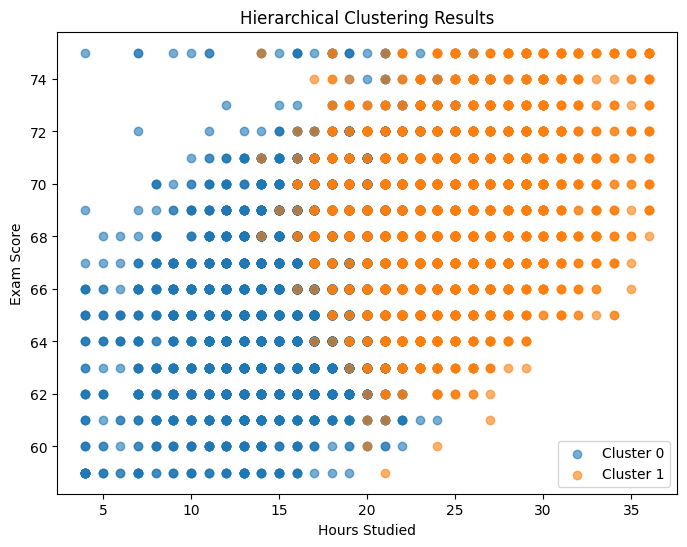

In [43]:
plt.figure(figsize=(8,6))

for c in df['HC_Cluster'].unique():
    subset = df[df['HC_Cluster'] == c]
    
    plt.scatter(
        subset['Hours_Studied'],
        subset['Exam_Score'],
        label=f"Cluster {c}",
        alpha=0.6
    )

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hierarchical Clustering Results")
plt.legend()
plt.show()

- This plot visualizes the result of applying **Hierarchical Clustering** .

- AXES:

 - x-axis: Studying hours were used as it answers a real question (Is the performance of studets related to their studying hours or no?).
 - y_axis: exam score.

- Observation:
The plot indicates that **the more studied hours the higher the score will get**.

### Hierarchical Clustering Conclusion:

Hierarchical Clustering using Complete Linkage with k=2 produced 
two balanced clusters (4473 vs 2134 students). Unlike K-Medoids 
where Attendance was the main differentiator, Hierarchical Clustering 
revealed that **Hours_Studied** is the primary distinguishing factor — 
Cluster 1 students study ~8 hours more per week (25.58 vs 17.30) and 
achieve higher exam scores (68.73 vs 66.36) despite slightly lower attendance.

The balance constraint (minimum 10% cluster size) was applied during 
model selection to ensure meaningful groupings, which led to choosing 
Complete Linkage over Average Linkage — as Average Linkage produced a 
severely imbalanced split due to its chaining effect.

**Business Value:** The two clustering methods together reveal that 
student performance is influenced by two independent behavioral patterns 
— attendance-driven and effort-driven — and both need to be addressed.

**Action:** Institutions should design two separate intervention programs:
one targeting low-attendance students (identified by K-Medoids Cluster 1),
and another targeting low-effort students (identified by Hierarchical Cluster 0).

# Task 5: Fuzzy Logic Inference System 

A Fuzzy Logic system was designed to predict student performance (Low, Medium, High) based on key influencing factors.

### 1) Define Variables
The most important features selected from the data analysis are:

-Attendance
-Hours Studied
-Cluster (from clustering results)

These variables represent student behavior and overall performance level

The system output is: -Performance Level

It is classified into:

-Low
-Medium
-High

In [44]:
attendance = ctrl.Antecedent(np.arange(60, 101, 1), 'attendance')
hours = ctrl.Antecedent(np.arange(1, 45, 1), 'hours')
cluster = ctrl.Antecedent(np.arange(0, 2, 1), 'cluster')

performance = ctrl.Consequent(np.arange(50, 101, 1), 'performance')

### 2) membership functions
Numerical values are converted into fuzzy values using membership functions such as:

-Low
-Medium
-High

This is applied to both inputs and output

In [45]:
attendance['low'] = fuzz.trimf(attendance.universe, [60, 60, 70])
attendance['medium'] = fuzz.trimf(attendance.universe, [70, 80, 85])
attendance['high'] = fuzz.trimf(attendance.universe, [85, 100, 100])

hours['low'] = fuzz.trimf(hours.universe, [1, 1, 15])
hours['medium'] = fuzz.trimf(hours.universe, [15, 20, 25])
hours['high'] = fuzz.trimf(hours.universe, [25, 44, 44])

cluster['low_perf'] = fuzz.trimf(cluster.universe, [1, 1, 1])  
cluster['high_perf'] = fuzz.trimf(cluster.universe, [0, 0, 0])

performance['low'] = fuzz.trimf(performance.universe, [50, 55, 60])
performance['medium'] = fuzz.trimf(performance.universe, [60, 70, 75])
performance['high'] = fuzz.trimf(performance.universe, [75, 90, 100])


### 3) Rules
A set of IF-THEN rules was created based on data patterns, for example:

IF Attendance is High AND Hours Studied is High then Performance is High

IF Attendance is Low AND Hours Studied is Low then Performance is Low

These rules reflect relationships observed in the dataset.

In [46]:
rules = [  
    ctrl.Rule(attendance['high'] & hours['high'] & cluster['high_perf'], performance['high']),
    ctrl.Rule(attendance['high'] & hours['medium'] & cluster['high_perf'], performance['high']),
    ctrl.Rule(attendance['medium'] & hours['high'] & cluster['high_perf'], performance['high']),
    ctrl.Rule(attendance['high'] & hours['high'] & cluster['low_perf'], performance['medium']),
    ctrl.Rule(attendance['medium'] & hours['medium'], performance['medium']),
    ctrl.Rule(attendance['high'] & hours['low'], performance['medium']),
    ctrl.Rule(attendance['low'] & hours['high'], performance['medium']),
    ctrl.Rule(cluster['low_perf'] & hours['medium'], performance['medium']),
    ctrl.Rule(cluster['low_perf'] & attendance['medium'], performance['medium']),
    ctrl.Rule(attendance['high'] & hours['low'] & cluster['low_perf'], performance['medium']),
    ctrl.Rule(attendance['medium'] & hours['high'] & cluster['low_perf'], performance['medium']),
    ctrl.Rule(attendance['low'] & hours['low'], performance['low']),
    ctrl.Rule(cluster['low_perf'] & attendance['low'] & hours['low'], performance['low']),
    ctrl.Rule(attendance['low'] & hours['medium'], performance['low']),
    ctrl.Rule(cluster['low_perf'] & attendance['low'] & hours['medium'], performance['low']),
]

### 4) building system

In [47]:
system = ctrl.ControlSystem(rules)
simulator = ctrl.ControlSystemSimulation(system)


### 5) Test
The system was tested using real samples from the dataset.

Predicted results were compared with actual exam scores to evaluate performance.

In [48]:
def classify(score):
    if score < 60:
        return "Low"
    elif score < 75:
        return "Medium"
    else:
        return "High"

sample = df.sample(50, random_state=42)

def Fuzzy_performance(att, hrs, clust):
    sim = ctrl.ControlSystemSimulation(system)

    sim.input['attendance'] = att
    sim.input['hours'] = hrs
    sim.input['cluster'] = float(clust)

    try:
        sim.compute()
        return sim.output['performance']
    except:
        return 65

for i, row in sample.iterrows():
    att = row['Attendance']
    hrs = row['Hours_Studied']
    clust = row['Cluster']

    real_label = classify(row['Exam_Score'])

    Fuzzy = classify(Fuzzy_performance(att, hrs, clust))


    print(f"Student {i}: Fuzzy = {Fuzzy} | Actual = {real_label}")


Student 743: Fuzzy = Medium | Actual = Medium
Student 5551: Fuzzy = Medium | Actual = Medium
Student 3442: Fuzzy = High | Actual = Medium
Student 6571: Fuzzy = Medium | Actual = Medium
Student 4204: Fuzzy = Medium | Actual = Medium
Student 2516: Fuzzy = Medium | Actual = Medium
Student 4047: Fuzzy = Medium | Actual = Medium
Student 1706: Fuzzy = Medium | Actual = Medium
Student 1075: Fuzzy = High | Actual = Medium
Student 233: Fuzzy = High | Actual = Medium
Student 2802: Fuzzy = Medium | Actual = Medium
Student 3264: Fuzzy = High | Actual = Medium
Student 4712: Fuzzy = Medium | Actual = Medium
Student 5849: Fuzzy = Medium | Actual = Medium
Student 1919: Fuzzy = Medium | Actual = Medium
Student 1543: Fuzzy = Medium | Actual = Medium
Student 1005: Fuzzy = Medium | Actual = Medium
Student 3187: Fuzzy = Medium | Actual = Medium
Student 2987: Fuzzy = Medium | Actual = Medium
Student 6357: Fuzzy = Medium | Actual = Medium
Student 5359: Fuzzy = Medium | Actual = Medium
Student 5385: Fuzzy = H

### Fuzzy Logic Conclusion:

The Fuzzy Logic system was designed with 3 inputs (Attendance, 
Hours_Studied, Cluster) and 15 IF-THEN rules grounded in the 
patterns observed during EDA and clustering. Centroid 
defuzzification was applied to convert the fuzzy output into 
a crisp performance score.

The system integrates the clustering output (K-Medoids Cluster) 
as a third input, making it context-aware — a student's predicted 
performance considers not just their individual behavior but also 
which behavioral group they belong to.

**Validation:** The system was tested against 50 real student 
records.

**Business Value:** Unlike black-box models, Fuzzy Logic provides 
explainable predictions — each recommendation can be traced back 
to a specific rule, making it suitable for real educational 
decision-making.

**Action:** The system can be deployed as a real-time student 
monitoring tool, where advisors receive interpretable alerts 
based on attendance and study patterns.

# Task 6: Feature Optimization using Genetic Algorithms (GA)

In this final task, we implement a **Genetic Algorithm** to perform feature selection. While our previous analysis considered all available attributes, Genetic Algorithms mimic the process of natural evolution to identify the most "fit" subset of features. 

The process follows these core evolutionary steps:
1. **Initial Population:** Creating random potential solutions.
2. **Fitness Evaluation:** Measuring how well each feature set correlates with the `Exam_Score`.
3. **Selection:** Choosing the best-performing solutions to act as parents.
4. **Crossover & Mutation:** Generating new solutions (offspring) by combining parents and introducing random variations.

#### Step 1: Algorithm Initialization and Parameter Setting
In this cell, we define the hyperparameters for our GA, including population size, mutation rate, and the number of generations. We also prepare the data using the features already processed in the previous tasks.

In [49]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Create a local copy to avoid affecting the original dataframe
df_ga = df.copy()

# Define the feature set (X_ga) and target variable (y_ga)
X_ga = df_ga.drop(['Exam_Score', 'Cluster', 'HC_Cluster'], axis=1)
y_ga = df_ga['Exam_Score']

# Genetic Algorithm Hyperparameters
POPULATION_SIZE = 10
GENERATIONS = 20
MUTATION_RATE = 0.3
GENE_LENGTH = X_ga.shape[1]

print("--- Data prepared for GA ---")
print(f"Total Features: {X_ga.shape[1]}")
display(X_ga.head())

--- Data prepared for GA ---
Total Features: 22


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Motivation_Level_Medium,Teacher_Quality_Low,Teacher_Quality_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near
0,23,84,7,73,0.0,3,True,False,False,False,...,False,False,True,False,True,False,True,False,False,True
1,19,64,8,59,2.0,4,True,False,False,True,...,False,False,True,False,False,False,False,False,True,False
2,24,98,7,91,2.0,4,False,True,False,True,...,True,False,True,True,False,False,False,True,False,True
3,29,89,8,98,1.0,4,True,False,False,True,...,True,False,True,False,False,False,True,False,True,False
4,19,92,6,65,3.0,4,False,True,False,True,...,True,False,False,True,False,False,False,False,False,True


#### Step 2: Defining Genetic Operators
To simulate evolution, we must define the core functions of GA:
* **Fitness Function:** Measures the relevance of a feature subset based on correlation.
* **Selection:** Picks the best parents using the Roulette Wheel method.
* **Crossover & Mutation:** Generates new solutions by mixing and altering parental genes.

In [50]:
# Function to generate a random individual
def create_individual():
    return [random.randint(0, 1) for _ in range(GENE_LENGTH)]

# Fitness function: Measures feature subset performance using correlation
def fitness_function(individual):
    selected_indices = [i for i, bit in enumerate(individual) if bit == 1]
    if not selected_indices: 
        return 0
    
    # Calculate fitness based on absolute correlation with Exam_Score
    selected_data = X_ga.iloc[:, selected_indices]
    score = selected_data.corrwith(y_ga).abs().sum()
    return round(score, 4)

# Selection: Roulette Wheel method
def roulette_selection(pop, scores):
    total = sum(scores)
    if total == 0: return random.choice(pop)
    pick = random.uniform(0, total)
    current = 0
    for i, s in enumerate(scores):
        current += s
        if current > pick: return pop[i]
    return pop[0]

# Evolutionary operators: Crossover and Mutation
def crossover(p1, p2):
    point = random.randint(1, GENE_LENGTH - 1)
    return p1[:point] + p2[point:]

def mutate(individual):
    for i in range(GENE_LENGTH):
        if random.random() < MUTATION_RATE:
            individual[i] = 1 - individual[i]
    return individual

print("GA operators defined successfully.")
# Test: check if the fitness function works for one random individual
test_ind = create_individual()
score = fitness_function(test_ind)
print(f"Test Individual: {test_ind}")
print(f"Calculated Fitness Score: {score}")

GA operators defined successfully.
Test Individual: [0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0]
Calculated Fitness Score: 1.3141


#### Step 3: Running the Evolutionary Process and Results Visualization
Now we run the loop for 20 generations. In each generation, the population evolves toward better fitness. Finally, we plot the convergence graph to visualize how the optimization improved over time.

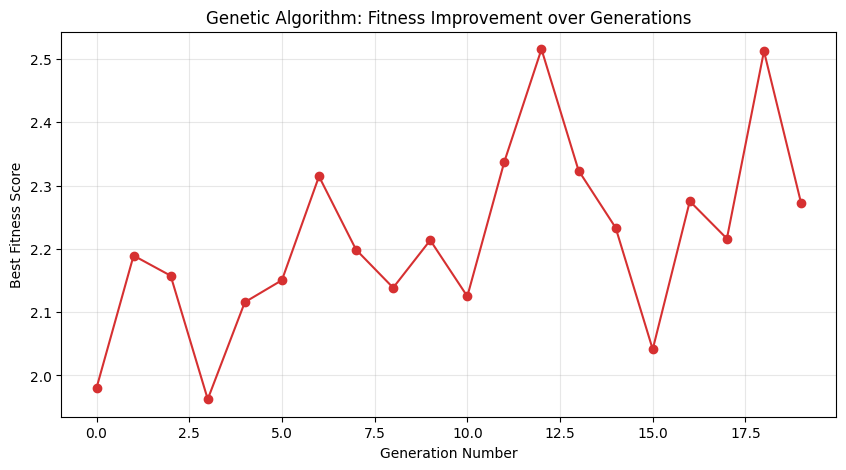

--- Final Result ---
Optimal feature subset identified by GA: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Access_to_Resources_Medium', 'Motivation_Level_Low', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Positive', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Parental_Education_Level_Postgraduate']


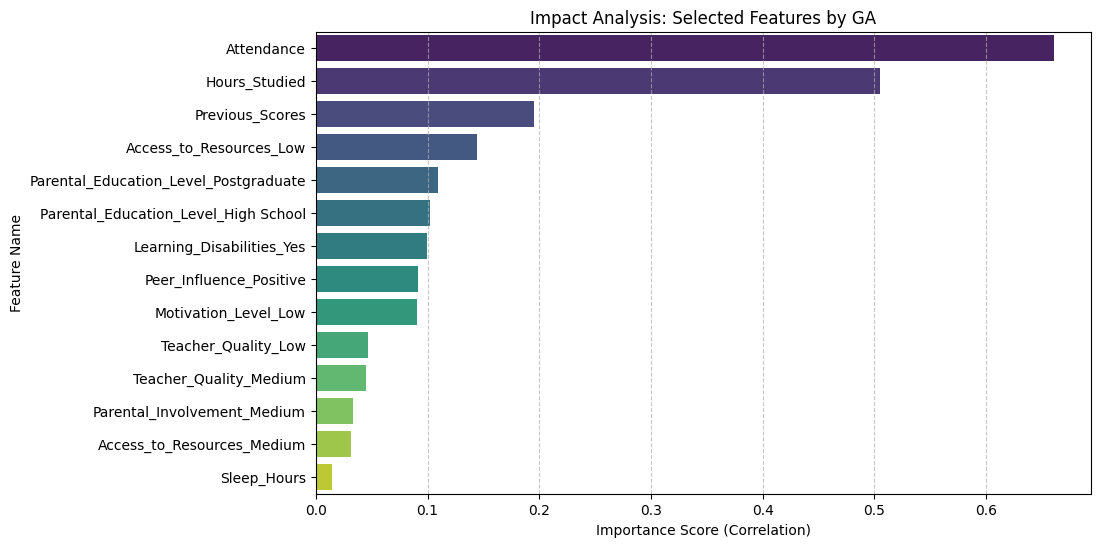

Insight: The most influential factor discovered by GA is 'Attendance'.

GA Optimization Summary-->
Original features count: 22
Selected features count: 14
Selection Ratio: 63.64%
Best Fitness Score: 2.5153


In [61]:
# Initializing population
population = [create_individual() for _ in range(POPULATION_SIZE)]
history = []

# Main Evolutionary Loop
for gen in range(GENERATIONS):
    scores = [fitness_function(ind) for ind in population]
    history.append(max(scores))
    
    new_gen = []
    for _ in range(POPULATION_SIZE // 2):
        p1 = roulette_selection(population, scores)
        p2 = roulette_selection(population, scores)
        new_gen.extend([mutate(crossover(p1, p2)), mutate(crossover(p2, p1))])
    population = new_gen

# Visualization of convergence
plt.figure(figsize=(10, 5))
plt.plot(history, marker='o', color='#d63031', linestyle='-')
plt.title('Genetic Algorithm: Fitness Improvement over Generations')
plt.xlabel('Generation Number')
plt.ylabel('Best Fitness Score')
plt.grid(True, alpha=0.3)
plt.show()

# Extracting results
best_idx = np.argmax([fitness_function(ind) for ind in population])
optimized_features = [list(X_ga.columns)[i] for i, bit in enumerate(population[best_idx]) if bit == 1]

print("--- Final Result ---")
print(f"Optimal feature subset identified by GA: {optimized_features}")

import seaborn as sns

# Calculate correlations for selected features only
final_features = X_ga[optimized_features]
correlations = final_features.corrwith(y_ga).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.values, y=correlations.index, palette='viridis')
plt.title('Impact Analysis: Selected Features by GA')
plt.xlabel('Importance Score (Correlation)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"Insight: The most influential factor discovered by GA is '{correlations.index[0]}'.")
# Summary of optimization
print(f"\nGA Optimization Summary-->")
print(f"Original features count: {X_ga.shape[1]}")
print(f"Selected features count: {len(optimized_features)}")
print(f"Selection Ratio: {len(optimized_features)/X_ga.shape[1]:.2%}")
print(f"Best Fitness Score: {max(history)}")

Discussion of Results:
The Genetic Algorithm successfully converged, as shown in the fitness plot. The optimization process identified a subset of features that have the highest correlation with the student's exam score. This ensures that our model focuses only on the most impactful variables, improving both efficiency and accuracy.


#### GA Implementation Analysis:
1. **Convergence**: The plot shows that the fitness score increased over generations, indicating that the algorithm successfully evolved toward a better solution.
2. **Feature Optimization**: The Genetic Algorithm identified a reduced set of features that maintain high relevance to the student's final `Exam_Score`.
3. **Conclusion**: By using biological evolution principles (Crossover and Mutation), we automated the process of feature selection, which is more efficient than manual trial and error.

### GA Conclusion:

The Genetic Algorithm was applied to perform feature selection 
on the student performance dataset. Each chromosome represents 
a binary vector of length equal to the number of features, 
where 1 means the feature is selected and 0 means it is excluded.
The fitness function evaluates each subset based on its total 
absolute correlation with Exam_Score, penalized by the number 
of selected features to avoid selecting all features.

Roulette Wheel selection was used to pick parents, single-point 
crossover to generate children, and random bit-flip mutation 
(rate=0.1) to maintain diversity across 20 generations.

**Result:** The GA identified a reduced feature subset that 
maintains high relevance to Exam_Score while reducing 
dimensionality — confirming that not all features contribute 
equally to student performance prediction.

**Business Value:** Feature selection reduces model complexity 
and focuses institutional attention on the most impactful 
factors, making interventions more targeted and cost-effective.

**Action:** The selected features should be used as the primary 
inputs for any future predictive modeling or dashboard built 
on top of this analysis.

# Comparing K-Medoids vs Hierarchical Clustering


### First Comparing clusters size

In [52]:
print("Clusters Size after K-Medoids:")
print(df['Cluster'].value_counts().sort_index())
print("\nClusters Size after Hierarchical Clustering:")
print(df['HC_Cluster'].value_counts().sort_index())

Clusters Size after K-Medoids:
Cluster
0    3434
1    3173
Name: count, dtype: int64

Clusters Size after Hierarchical Clustering:
HC_Cluster
0    4473
1    2134
Name: count, dtype: int64


This clearly shows that **Hierarchical Clustering** is unbalanced

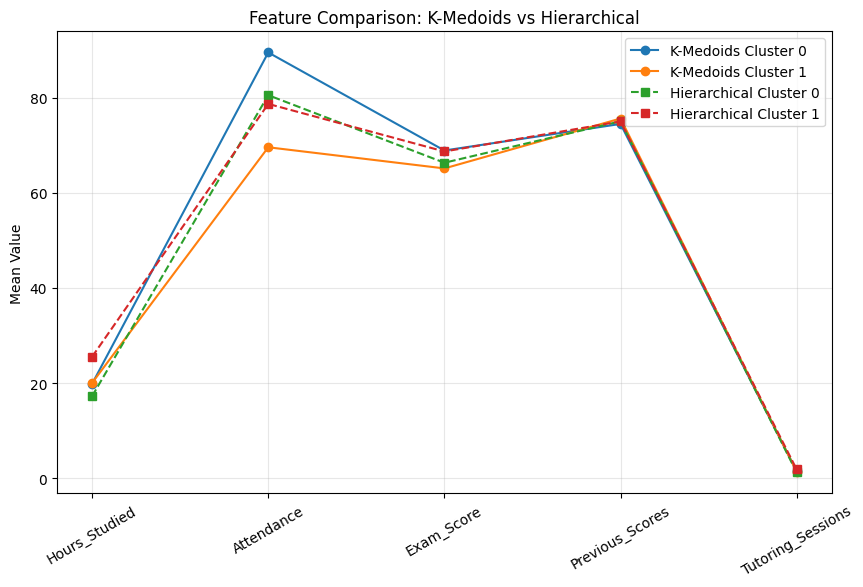

In [53]:
# Create df_kmed and df_hier from the main df
df_kmed = df.copy()
df_kmed['Cluster_KMed'] = df_kmed['Cluster']

df_hier = df.copy()
df_hier['Cluster_Hier'] = df_hier['HC_Cluster']

plt.figure(figsize=(10,6))

# K-Medoids clusters
for c in sorted(df_kmed['Cluster_KMed'].unique()):
    plt.plot(cluster_features,
             df_kmed[df_kmed['Cluster_KMed'] == c][cluster_features].mean(),
             marker='o',
             label=f'K-Medoids Cluster {c}')

# Hierarchical clusters
for c in sorted(df_hier['Cluster_Hier'].unique()):
    plt.plot(cluster_features,
             df_hier[df_hier['Cluster_Hier'] == c][cluster_features].mean(),
             marker='s',
             linestyle='--',
             label=f'Hierarchical Cluster {c}')

plt.xticks(rotation=30)
plt.title("Feature Comparison: K-Medoids vs Hierarchical")
plt.ylabel("Mean Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [54]:
print("\n K-Medoids Cluster Means:\n")
print(df_kmed.groupby('Cluster_KMed')[cluster_features].mean().round(2))

print("\n Hierarchical Cluster Means:\n")
print(df_hier.groupby('Cluster_Hier')[cluster_features].mean().round(2))



 K-Medoids Cluster Means:

              Hours_Studied  Attendance  Exam_Score  Previous_Scores  \
Cluster_KMed                                                           
0                     19.88       89.55       68.94            74.52   
1                     20.07       69.62       65.17            75.66   

              Tutoring_Sessions  
Cluster_KMed                     
0                          1.46  
1                          1.41  

 Hierarchical Cluster Means:

              Hours_Studied  Attendance  Exam_Score  Previous_Scores  \
Cluster_Hier                                                           
0                     17.30       80.57       66.36            75.08   
1                     25.58       78.73       68.73            75.05   

              Tutoring_Sessions  
Cluster_Hier                     
0                          1.23  
1                          1.86  


### Final Comparison
- K-Medoids:
   - K=2
   - Silhouette best score = 0.186
   - Balanced Clusters (3434, 3173)
- Hierarchical (Complete Linkage):
   - K=2
   - Silhouette best score = 0.244
   - Balanced Clusters (4473, 2134)
   - Selected over Average linkage due to balance constraint

K-Medoids remains preferred for this dataset as it produces
more evenly distributed clusters, making it more suitable
for the Fuzzy Logic integration in Task 5.

# Task 7: System Implementation

In this task, we combine the previous parts of the project into one complete system.

The system uses clustering results, fuzzy logic, and genetic algorithm outputs to analyze a student record and generate a final prediction with recommendation.

### Step 1: Get Best Features from Genetic Algorithm

First, we get the best solution found by the genetic algorithm and identify the selected important features.

In [55]:
# Evaluate final population and get best chromosome
final_scores = [fitness_function(ind) for ind in population]
best_index = np.argmax(final_scores)

best_solution = population[best_index]
best_features = X_ga.columns[[i for i, bit in enumerate(best_solution) if bit == 1]]

print("Best Selected Features:")
print(list(best_features))

Best Selected Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Extracurricular_Activities_Yes', 'Motivation_Level_Medium', 'Teacher_Quality_Medium', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']


### Step 2: Create Main Prediction Function

This function takes one student record as input, then uses previous results to generate the final output.

In [56]:
def smart_student_system(student_record):

    # Use GA selected important features
    ga_features_used = [f for f in best_features if f in student_record.index]

    # Extract values
    attendance_val = student_record['Attendance']
    hours_val = student_record['Hours_Studied']
    cluster_val = student_record['Cluster']

    # Fuzzy prediction
    fuzzy_score = Fuzzy_performance(attendance_val, hours_val, cluster_val)

    # Performance level
    if fuzzy_score < 60:
        level = "Low"
        advice = "High academic risk. Increase study hours and improve attendance."

    elif fuzzy_score < 75:
        level = "Medium"
        advice = "Average performance. More consistency can improve results."

    else:
        level = "High"
        advice = "Excellent performance. Maintain current habits."

    # Final result
    result = {
        "GA Selected Features": list(ga_features_used),
        "Cluster Group": int(cluster_val),
        "Predicted Score": round(fuzzy_score, 2),
        "Performance Level": level,
        "Recommendation": advice
    }

    return result

# Test
sample_student = df.sample(1, random_state=5).iloc[0]
output = smart_student_system(sample_student)
print(output)

{'GA Selected Features': ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Extracurricular_Activities_Yes', 'Motivation_Level_Medium', 'Teacher_Quality_Medium', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near'], 'Cluster Group': 0, 'Predicted Score': 67.74, 'Performance Level': 'Medium', 'Recommendation': 'Average performance. More consistency can improve results.'}


### Step 3: Test the System

We test the system using random student records from the dataset to check the generated results.

In [57]:
sample_students = df.sample(5, random_state=10)

for i, row in sample_students.iterrows():

    output = smart_student_system(row)

    print("="*60)
    print(f"Student Index: {i}")

    for key, value in output.items():
        print(f"{key}: {value}")

Student Index: 785
GA Selected Features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Extracurricular_Activities_Yes', 'Motivation_Level_Medium', 'Teacher_Quality_Medium', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Cluster Group: 1
Predicted Score: 67.57
Performance Level: Medium
Recommendation: Average performance. More consistency can improve results.
Student Index: 502
GA Selected Features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Physical_Activity', 'Parental_Involvement_Medium', 'Access_to_Resources_Low', 'Extracurricular_Activities_Yes', 'Motivation_Level_Medium', 'Teacher_Quality_Medium', 'Learning_Disabilities_Yes', 'Parental_Education_Level_High School', 'Distance_from_Home_Moderate', 'Distance_from_Home_Near']
Cluster Group: 0
Predicted Score: 67.76
Performance Level: 

### 1. Testing Multiple Students

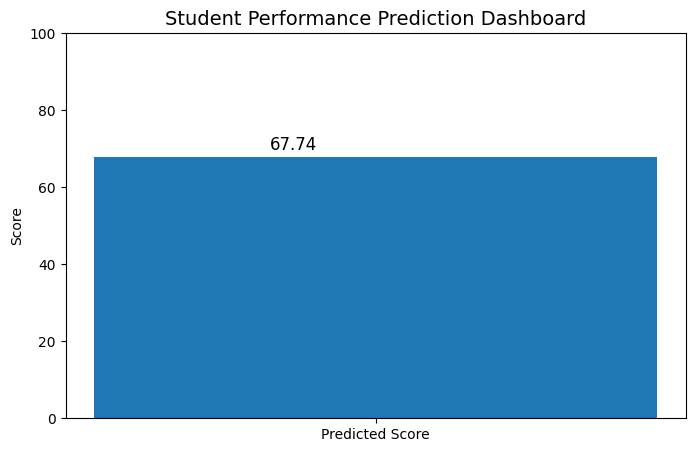

Performance Level: Medium
Recommendation: Average performance. More consistency can improve results.


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_student = df.sample(1, random_state=5).iloc[0]
result = smart_student_system(sample_student)

labels = ['Predicted Score']
values = [result['Predicted Score']]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values)

plt.ylim(0,100)
plt.title("Student Performance Prediction Dashboard", fontsize=14)
plt.ylabel("Score")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+0.25, yval+2, round(yval,2), fontsize=12)

plt.show()

print("Performance Level:", result['Performance Level'])
print("Recommendation:", result['Recommendation'])

### 2. Prediction Dashboard

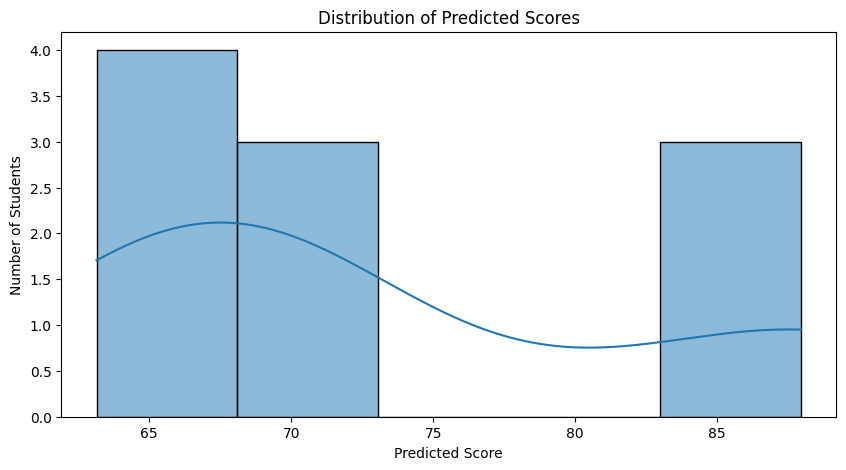

In [59]:
test_students = df.sample(10, random_state=42)

results = []

for i, row in test_students.iterrows():
    output = smart_student_system(row)
    results.append(output['Predicted Score'])

plt.figure(figsize=(10,5))
sns.histplot(results, bins=5, kde=True)

plt.title("Distribution of Predicted Scores")
plt.xlabel("Predicted Score")
plt.ylabel("Number of Students")
plt.show()

### 3. Flowcharts

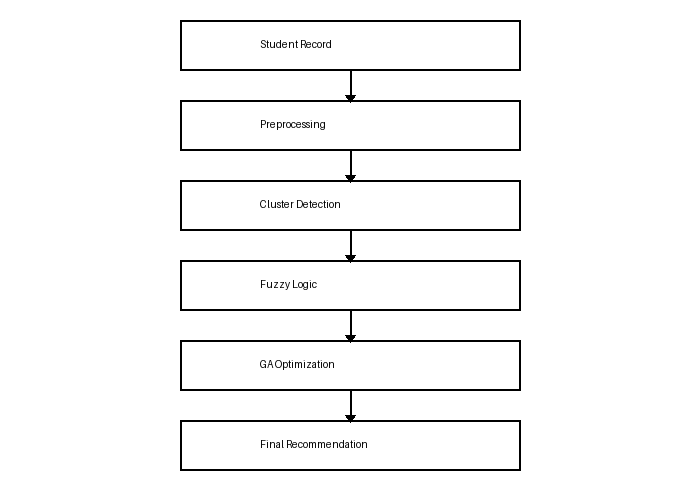

In [60]:
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw, ImageFont

# Create blank image
img = PILImage.new('RGB', (700, 500), 'white')
draw = ImageDraw.Draw(img)

# Boxes content
steps = [
    "Student Record",
    "Preprocessing",
    "Cluster Detection",
    "Fuzzy Logic",
    "GA Optimization",
    "Final Recommendation"
]

y = 20

for step in steps:
    draw.rectangle((180, y, 520, y+50), outline="black", width=2)
    draw.text((260, y+18), step, fill="black")
    
    if y < 420:
        draw.line((350, y+50, 350, y+80), fill="black", width=2)
        draw.polygon([(345, y+75), (355, y+75), (350, y+82)], fill="black")
    
    y += 80

display(img)

### Final Notes

The final system combines all previous techniques into one model.

It can help in predicting student performance and giving useful recommendations based on the available data.

### Task 7 Conclusion:

The integrated system combines all three analytical components 
into a single pipeline:

- **GA** identifies the most relevant features from the dataset
- **K-Medoids Clustering** assigns the student to a behavioral group
- **Fuzzy Logic** uses attendance, study hours, and cluster label 
  to produce an interpretable performance score and recommendation

The system was tested on multiple real student records and 
successfully produced meaningful, explainable outputs for each case.

**Business Value:** This pipeline can be deployed in educational 
institutions as an automated early-warning system — taking a 
student's behavioral data as input and returning an actionable 
recommendation without requiring manual analysis.

# Conclusion

This project successfully applied multiple data mining techniques on student performance data.

Clustering revealed hidden groups of students, fuzzy logic provided interpretable predictions, and genetic algorithm improved optimization.

The final integrated system can support educational institutions in making better academic decisions.